### 42028 : Deep Learning and CNN
### Assignment 2

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To perform Image Classification using baseline VGG16 CNN architectures

### Contents
1. Section 1 : Original Data Loading and Splitting
2. Section 2 : Image Resizing and Augmentation for VGG16
3. Section 3 : Baseline VGG16 Modelling

### Drive Mounting

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# !unzip ./drive/MyDrive/UTS_Academics/42904_Deep_Learning/Assignment_2/student_25675238.zip -d ./drive/MyDrive/UTS_Academics/42904_Deep_Learning/Assignment_2/

### System GPU Checks

In [1]:
#Check GPU
!nvidia-smi

Wed May 13 22:43:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   32C    P0             30W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!find / -type f -name "libdevice.10.bc" 2>/dev/null

/opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc


/opt/conda/nvvm/libdevice/libdevice.10.bc


### Library Imports

In [3]:
!pip install opencv-python --quiet

In [4]:
!pip install pydot

In [5]:
!pip install silence-tensorflow

In [6]:
!pip install numpy

In [3]:
# Importing required libraries and setting global variables
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=-1'
os.environ['TF_XLA_AUTO_JIT'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [5]:
import pydot
import random
import seaborn as sns
import tensorflow as tf
dataset_path = './25675238/Image_Classification/dataset'
data_files_path = './data_files/Image_Classification'
results_files_path = './results_and_models'

E0000 00:00:1778711262.290989    3166 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778711262.305431    3166 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778711262.336882    3166 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778711262.336927    3166 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778711262.336931    3166 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778711262.336933    3166 computation_placer.cc:177] computation placer already registered. Please check linka

In [6]:
from tensorflow import keras
from datetime import datetime
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import models
from keras import layers
from keras import optimizers
from keras.models import load_model
from keras.applications import VGG16, InceptionV3
from keras.applications.vgg16 import preprocess_input as vgg_process_input
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_process_input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from silence_tensorflow import silence_tensorflow

In [7]:
tf.get_logger().setLevel('ERROR')
silence_tensorflow()

### Section 1 : Original Data Loading and Splitting

In [8]:
# Loading the preprocessed images from npz files
with np.load(data_files_path + '/original_images.npz', allow_pickle=True) as data:
    images = list(data['arr_0'])

In [9]:
# Loading the original labels from the npz files
with np.load(data_files_path + '/original_labels.npz', allow_pickle=True) as data:
    labels = list(data['arr_0'])

In [10]:
# Encoding labels
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

In [11]:
# Creating training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, encoded_labels,
    test_size=0.15,
    train_size=0.85,
    random_state=25675238 #Using student ID as random seed
)

In [12]:
# Creating validation set
images_valid = images_train[:250]
labels_valid = labels_train[:250]

images_train = images_train[250:]
labels_train = labels_train[250:]

*The dataset is initially split into 85% training set and 15% testing set.*

*The training set is split into another 70% and 15% validation set*

### Section 2 : Images resizing and Augmentation for VGG16

In [19]:
# Image resizing
# The images of variable length are resized to 224x224 to standardize the input to the baseline models
resize_train_image = []
resize_valid_image = []
resize_test_image = []

for img in images_train:
    rsz_img = cv2.resize(img, (224, 224))
    resize_train_image.append(rsz_img)
for img in images_valid:
    rsz_img = cv2.resize(img, (224, 224))
    resize_valid_image.append(rsz_img)
for img in images_test:
    rsz_img = cv2.resize(img, (224, 224))
    resize_test_image.append(rsz_img)

In [20]:
# Converting list of images to numpy array for model training
images_train = np.asarray(resize_train_image).astype('float32')
images_valid = np.asarray(resize_valid_image).astype('float32')
images_test = np.asarray(resize_test_image).astype('float32')

In [24]:
labels_train = np.asarray(labels_train)
labels_valid = np.asarray(labels_valid)
labels_test = np.asarray(labels_test)

In [25]:
classes = os.listdir(dataset_path)
classes

['borzoi',
 'toy_terrier',
 'wire-haired_fox_terrier',
 'schipperke',
 'chihuahua',
 'sussex_spaniel',
 'bernese_mountain_dog',
 'norwegian_elkhound',
 'german_short-haired_pointer',
 'brittany_spaniel']

In [26]:
# Creating augmentation samples for visualization
augmented_samples_path = './augmented_samples'

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

for name in classes:
    i = 0
    for batch in datagen.flow(
        images_train,
        labels_train,
        batch_size=1,
        save_to_dir=augmented_samples_path, 
        save_prefix=f'aug_{name}', 
        save_format='jpeg'
    ):
        i += 1
        if i >= 2:
            break 
    print(f"Created 2 samples for {name}")

# Cleanup augmented samples
!rm -r ./augmented_samples/.ipynb_checkpoints

Created 2 samples for borzoi
Created 2 samples for toy_terrier
Created 2 samples for wire-haired_fox_terrier
Created 2 samples for schipperke
Created 2 samples for chihuahua
Created 2 samples for sussex_spaniel
Created 2 samples for bernese_mountain_dog
Created 2 samples for norwegian_elkhound
Created 2 samples for german_short-haired_pointer
Created 2 samples for brittany_spaniel


rm: cannot remove './augmented_samples/.ipynb_checkpoints': No such file or directory


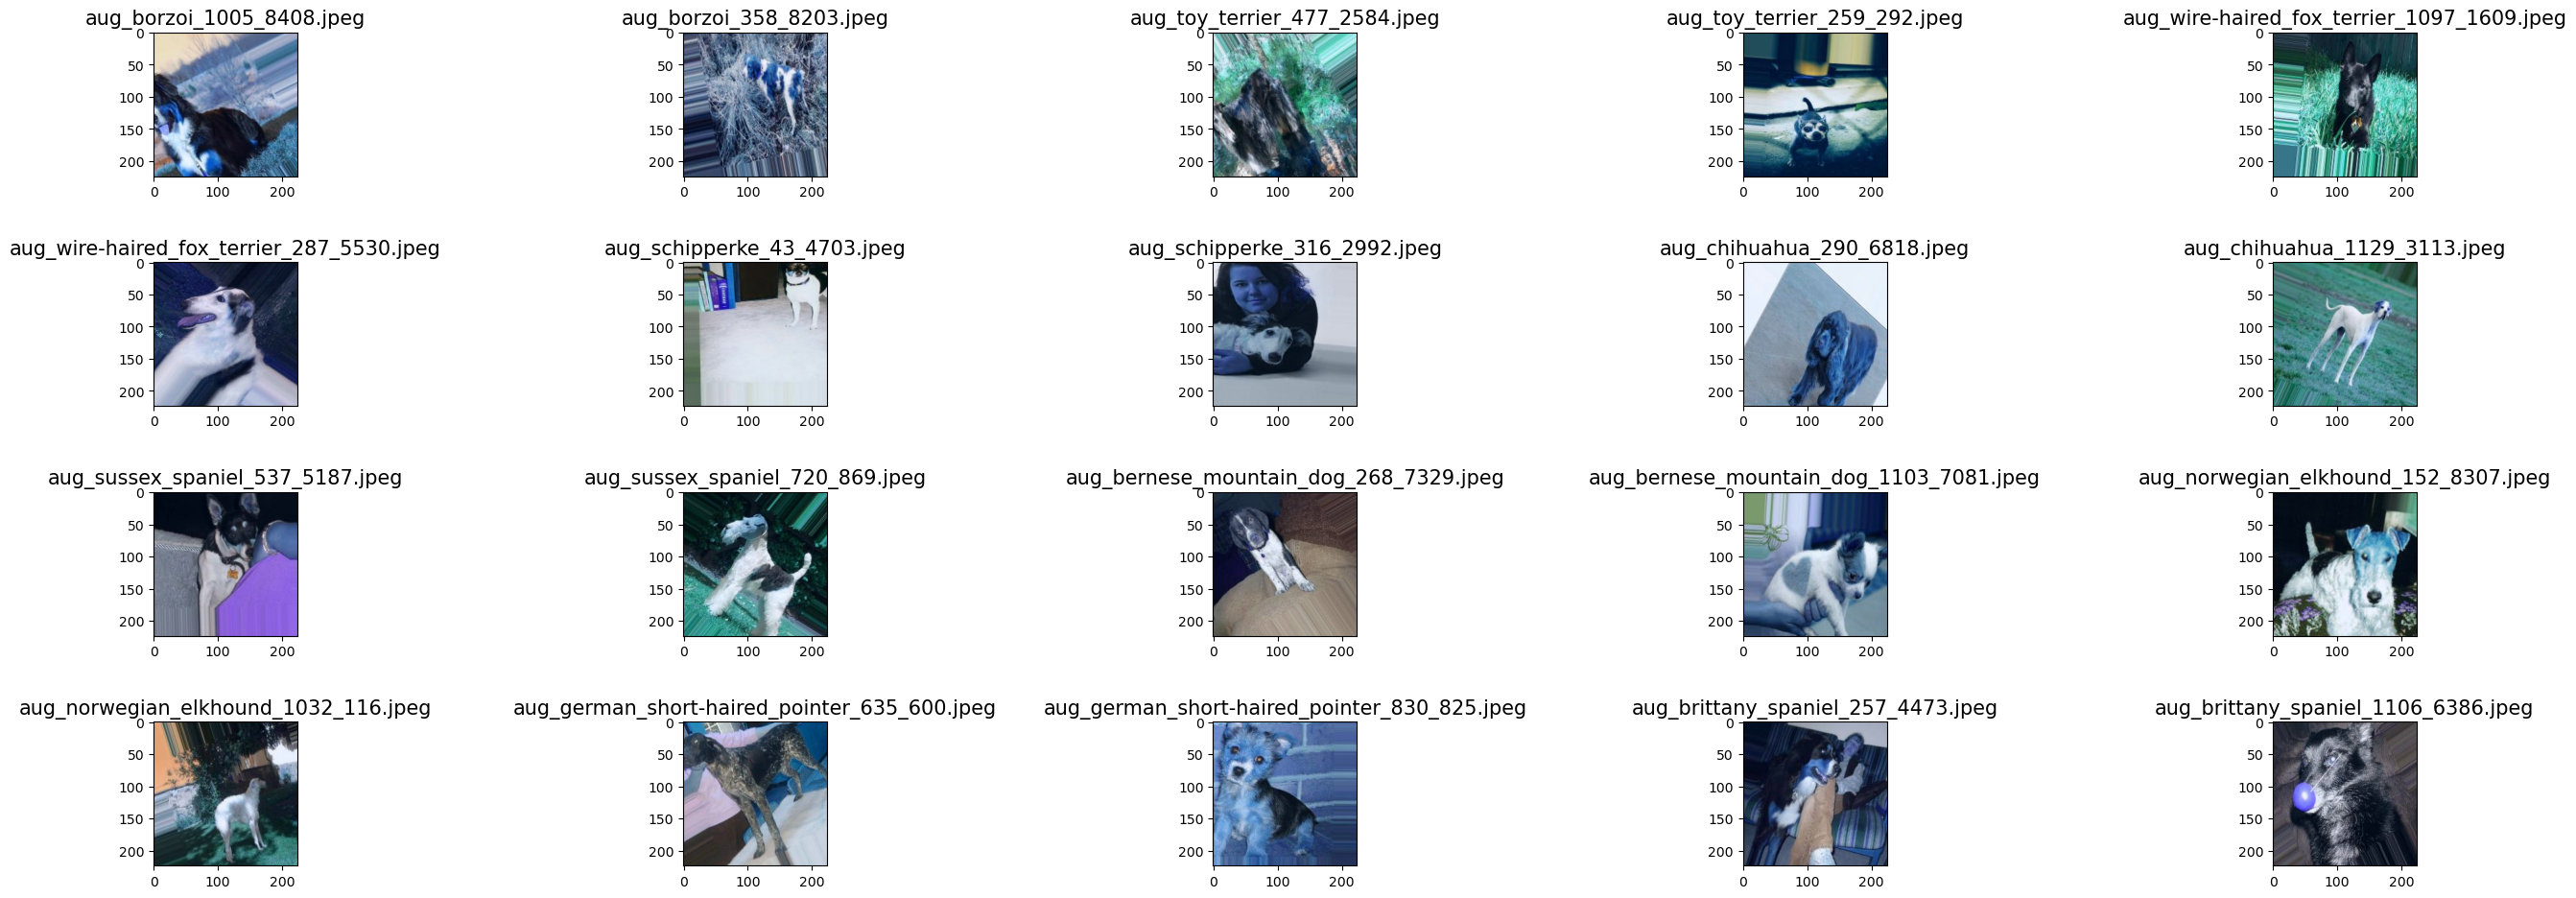

In [27]:
# Analysing augmented images from every class

fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(30,10))
augmented_images = os.listdir(augmented_samples_path)
aug_img_idx = 0
for i in range(4):
    for j in range(5):
        img = cv2.imread(augmented_samples_path + "/" + augmented_images[aug_img_idx])
        axes[i,j].imshow(img)
        axes[i,j].set_title(augmented_images[aug_img_idx], fontsize=15)
        aug_img_idx += 1
plt.tight_layout(pad=3.0)
plt.show()

In [29]:
# Cleanup augmented samples
!rm -rf ./augmented_samples/*

In [21]:
train_datagen = ImageDataGenerator(
      preprocessing_function=preprocess_input,
      rotation_range=20,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest'
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow(
    images_train,
    labels_train,
    batch_size=36,
    seed=25675238
)

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow(
    images_valid,
    labels_valid,
    batch_size=36,
    seed=25675238
)

### Section 3: Baseline CNN Modelling (VGG16)

In [22]:
# Using VGG16 model with pretrained weights
conv_base = VGG16(weights='imagenet',include_top=False, input_shape=(224, 224, 3))
model = models.Sequential()
model.add(conv_base)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

I0000 00:00:1778676347.631109     662 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [23]:
# Freezing the convolutional base of the VGG16 model
for layer in conv_base.layers[:-4]: 
    layer.trainable = False

In [24]:
# Model compilation
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### VGG16 Model Fit

In [25]:
# Checkpointing model weights as per progress
filepath = './results_and_models/baseline_vgg_weights/weights_modified.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    save_freq='epoch'
)

In [26]:
# CSV logger for adding results to a .csv file
csv_logger = CSVLogger('./results_and_models/baseline_vgg_logs.csv', append=False, separator=',')

In [27]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.2,   # Drop LR by 80%
    patience=5,   # Wait 5 epochs before dropping
    min_lr=1e-7
)

In [28]:
early_stop = EarlyStopping(
    monitor='val_accuracy',   # Or 'val_loss'
    patience=10,              # How many epochs to wait for an improvement
    verbose=1,                # Notifies you when it stops
    restore_best_weights=True # Rolls back to the "best" version of the model
)

In [29]:
# Train the model
history = model.fit(
    train_generator,
    epochs=100,
    steps_per_epoch = 32,
    validation_data=validation_generator,
    validation_steps=8,
    callbacks = [checkpoint, csv_logger, reduce_lr, early_stop],
    verbose=0
    )

I0000 00:00:1778676380.012906    1127 service.cc:152] XLA service 0x7f2084015060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778676380.012934    1127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-13 12:46:20.164134: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1778676380.642967    1127 cuda_dnn.cc:529] Loaded cuDNN version 91002


2026-05-13 12:46:21.463554: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.39 = (f32[36,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,3,224,224]{3,2,1,0} %bitcast.4717, f32[64,3,3,3]{3,2,1,0} %bitcast.4724, f32[64]{0} %bitcast.4726), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block1_conv1_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-05-13 12:46:21.663713: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted

2026-05-13 12:46:23.971700: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.41 = (f32[36,128,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,64,112,112]{3,2,1,0} %bitcast.4747, f32[128,64,3,3]{3,2,1,0} %bitcast.4754, f32[128]{0} %bitcast.4756), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block2_conv1_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}


2026-05-13 12:46:25.033641: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.42 = (f32[36,128,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,128,112,112]{3,2,1,0} %bitcast.4761, f32[128,128,3,3]{3,2,1,0} %bitcast.4768, f32[128]{0} %bitcast.4770), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block2_conv2_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}


...


Epoch 55: val_accuracy did not improve from 0.90000



Epoch 56: val_accuracy did not improve from 0.90000



Epoch 57: val_accuracy did not improve from 0.90000


Epoch 57: early stopping


Restoring model weights from the end of the best epoch: 47.


In [30]:
model_save_path = results_files_path + '/baseline_vgg__models/'
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = model_save_path + f"vgg16_model_{timestamp}.keras"
model.save(model_name)

#### VGG16 Model Results

In [31]:
# Retrieving the latest model
saved_models = os.listdir(model_save_path)
saved_models.sort(reverse=True)
latest_model_path = model_save_path + saved_models[0]
print("Loading latest model = ", latest_model_path)
model_vgg = load_model(latest_model_path)

Loading latest model =  ./results_and_models/baseline_models/vgg16_model_20260513_125551.keras


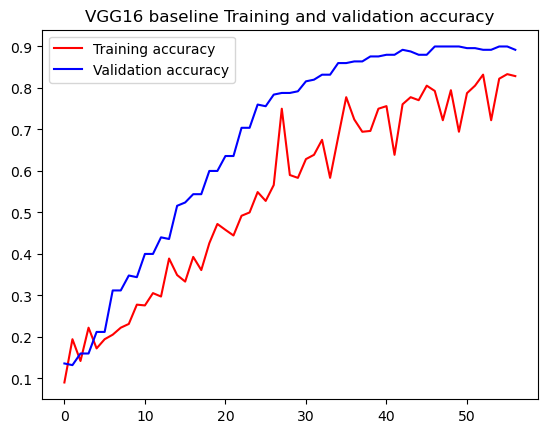

<Figure size 640x480 with 0 Axes>

In [32]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('VGG16 baseline Training and validation accuracy')
plt.legend()
plt.show()
plt.savefig('./results_and_models/VGG16_Baseline_Accuracy.png')

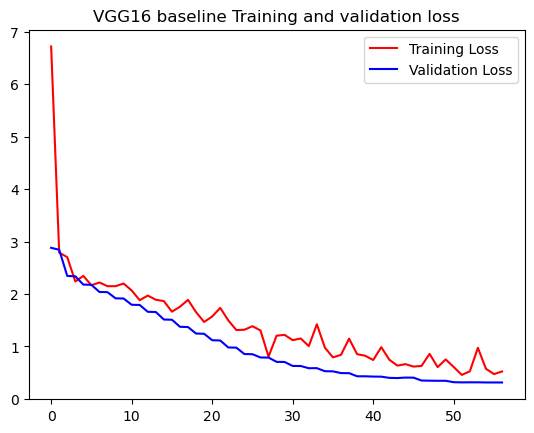

In [33]:
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('VGG16 baseline Training and validation loss')
plt.legend()
plt.savefig('./results_and_models/VGG16_Baseline_Loss.png')

#### VGG16 Model Predictions

In [35]:
model_vgg_predictions = model_vgg.predict(images_test)

1/8 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step

2/8 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

3/8 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step

4/8 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step


In [36]:
lables_vgg_predict = np.argmax(model_vgg_predictions, axis=1)

In [37]:
len(labels_test)

249

In [38]:
len(lables_vgg_predict)

249

In [39]:
# Reversing the encoding
labels_test_names = encoder.inverse_transform(labels_test)
labels_vgg_pred_names = encoder.inverse_transform(lables_vgg_predict)

In [48]:
# Calculate Accuracy
accuracy = accuracy_score(labels_test_names, labels_vgg_pred_names)
print(f"Accuracy: {accuracy:.4f}")

# Detailed breakdown
print(classification_report(labels_test_names, labels_vgg_pred_names))

Accuracy: 0.7711
                             precision    recall  f1-score   support

       bernese_mountain_dog       0.73      0.73      0.73        30
                     borzoi       0.62      1.00      0.76        24
           brittany_spaniel       0.50      0.27      0.35        22
                  chihuahua       0.56      0.50      0.53        18
german_short-haired_pointer       0.77      0.80      0.78        25
         norwegian_elkhound       0.97      0.84      0.90        37
                 schipperke       0.88      0.79      0.83        19
             sussex_spaniel       0.89      0.85      0.87        20
                toy_terrier       0.74      0.84      0.79        31
    wire-haired_fox_terrier       0.96      0.96      0.96        23

                   accuracy                           0.77       249
                  macro avg       0.76      0.76      0.75       249
               weighted avg       0.77      0.77      0.76       249



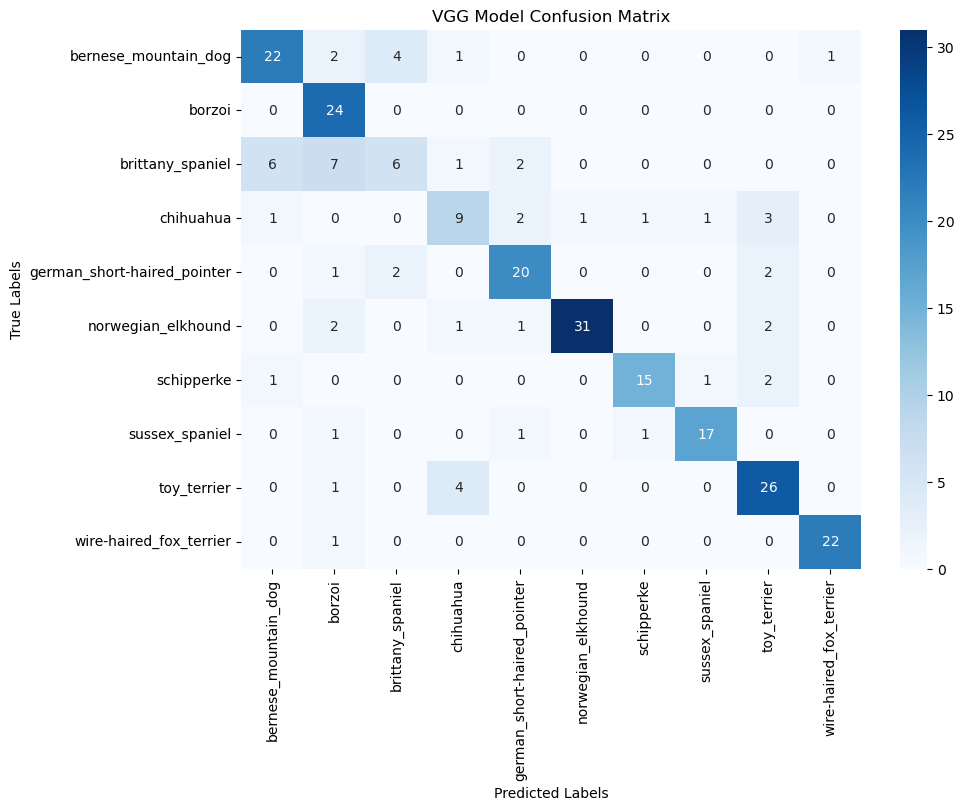

In [63]:
# Plotting confusion matrix
cm = confusion_matrix(labels_test, lables_vgg_predict)

# Plot using Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('VGG Model Confusion Matrix')
plt.show()

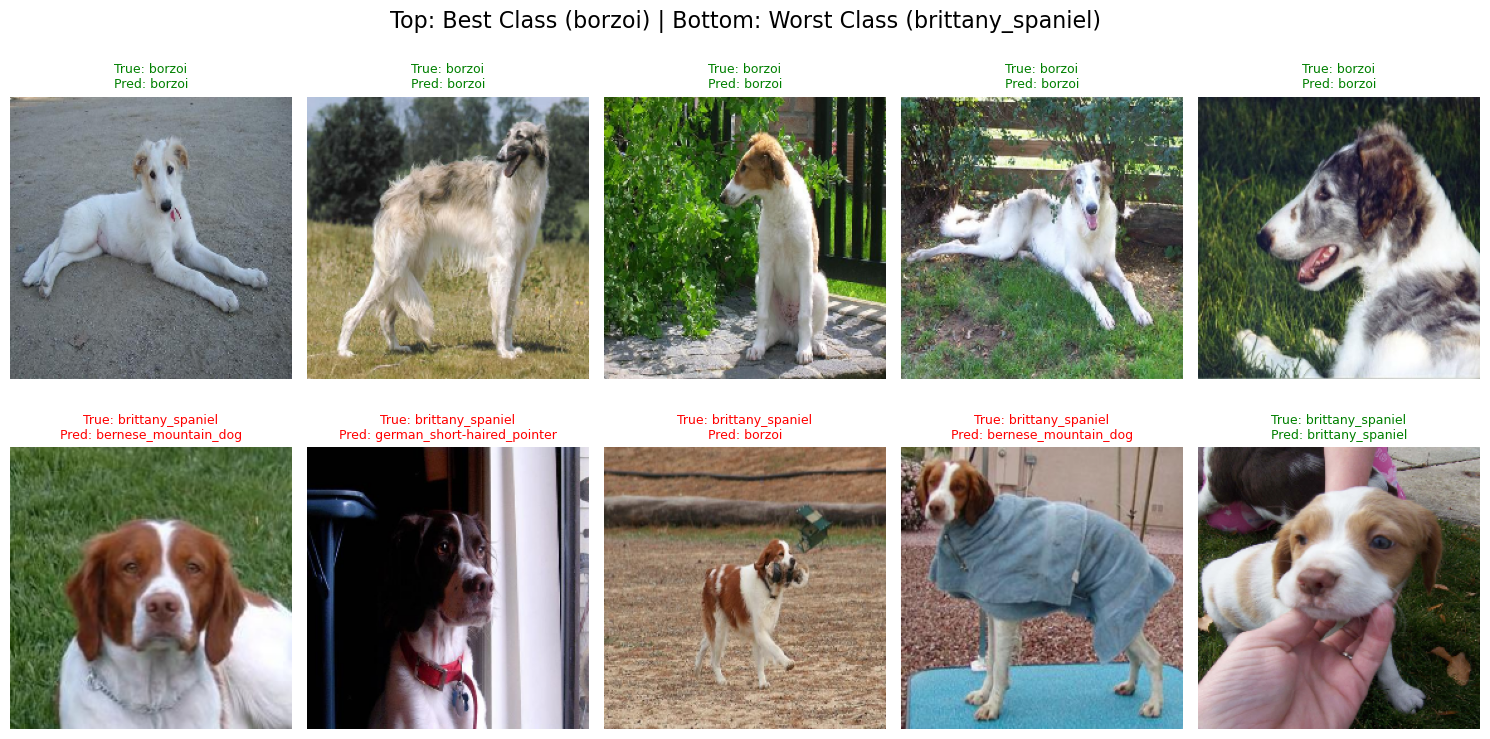

In [65]:
# Visualising the best and the worst class label predictions from VGG16
# Calculating recall score 
per_class_acc = recall_score(labels_test, lables_vgg_predict, average=None)
best_class_idx = np.argmax(per_class_acc)
worst_class_idx = np.argmin(per_class_acc)

best_name = encoder.inverse_transform([best_class_idx])[0]
worst_name = encoder.inverse_transform([worst_class_idx])[0]

def plot_samples(class_idx, title_prefix, start_subplot):
    indices = np.where(labels_test == class_idx)[0][:5]
    
    for i, idx in enumerate(indmzices):
        plt.subplot(2, 5, start_subplot + i)
        plt.imshow(images_test[idx][..., ::-1].astype('uint8'))
        
        actual = encoder.inverse_transform([labels_test[idx]])[0]
        pred = encoder.inverse_transform([lables_vgg_predict[idx]])[0]
        
        color = 'green' if actual == pred else 'red'
        plt.title(f"True: {actual}\nPred: {pred}", color=color, fontsize=9)
        plt.axis('off')


plt.figure(figsize=(15, 8))
plt.suptitle(f"Top: Best Class ({best_name}) | Bottom: Worst Class ({worst_name})", fontsize=16)
plot_samples(best_class_idx, "Best", 1)
plot_samples(worst_class_idx, "Worst", 6)
plt.tight_layout()
plt.show()